# 01 — Numeric block: EDA + iterative training

**Goal:** Build a regression model that, given the *predicted disease class* and the user's *growing conditions* (soil NPK, temperature, humidity, pH, rainfall), returns a **disease-progression risk score (0-100)**.

**Data source.** The numeric dataset is produced by `prepare_data.py`. The schema reuses the columns of the Kaggle *Crop Recommendation* dataset (N, P, K, temperature, humidity, ph, rainfall) and adds a disease label plus a literature-grounded `risk_score`.

**Why this block exists.** The CV model only tells us *which* disease is on the leaf. It says nothing about how aggressively the disease will progress under the user's local conditions. The numeric model fills that gap and turns the categorical CV prediction into an actionable risk number that the NLP block can reason about.

In [14]:
import json
import os
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_style('whitegrid')

PROJECT_ROOT = Path('..').resolve()
DATA_PATH = PROJECT_ROOT / 'data' / 'plant_disease_risk_dataset.csv'
MODEL_DIR = PROJECT_ROOT / 'models'
RANDOM_STATE = 42

## 1. Load data

In [15]:
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(3750, 12)


,crop,disease,healthy,N,P,K,temperature,humidity,ph,rainfall,risk_score,risk_category
0,Tomato,Tomato___healthy,1,108.353847,66.442982,176.719584,33.105249,23.005075,9.353734,233.119117,14.478384,Low
1,Tomato,Tomato___healthy,1,110.049003,22.935909,95.077188,21.348729,93.775024,7.363191,250.373252,9.306278,Low
2,Tomato,Tomato___healthy,1,62.077988,36.813421,115.916957,10.297421,85.348650,7.289986,232.264567,13.024915,Low
3,Tomato,Tomato___healthy,1,49.633636,140.897723,183.624224,36.021806,31.544290,6.300326,32.265054,16.718636,Low
4,Tomato,Tomato___healthy,1,21.600529,100.626853,153.952431,42.830350,42.695155,5.722758,151.475627,14.169268,Low


In [16]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
healthy,3750.0,0.333333,0.471467,0.000000,0.000000,0.000000,1.000000,1.000000
N,3750.0,69.391196,40.413133,0.015231,34.005267,69.836388,103.966928,139.954691
P,3750.0,74.906835,40.635878,5.058368,39.305478,74.948176,109.741725,144.996783
K,3750.0,105.725080,57.609611,5.024981,56.190199,107.124528,155.487794,204.996498
temperature,3750.0,25.949745,10.367972,8.006828,17.041353,25.977496,34.855885,43.989735
humidity,3750.0,57.772148,24.748871,15.001119,36.218326,57.074614,79.772599,99.995517
ph,3750.0,6.529501,1.738820,3.501027,5.036253,6.554513,8.045913,9.499628
rainfall,3750.0,158.510820,80.293097,20.005387,87.742376,159.503267,228.118385,299.961037
risk_score,3750.0,39.846528,25.091445,3.188167,13.518610,39.338462,59.360352,100.000000


## 2. EDA

### 2.1 Class balance

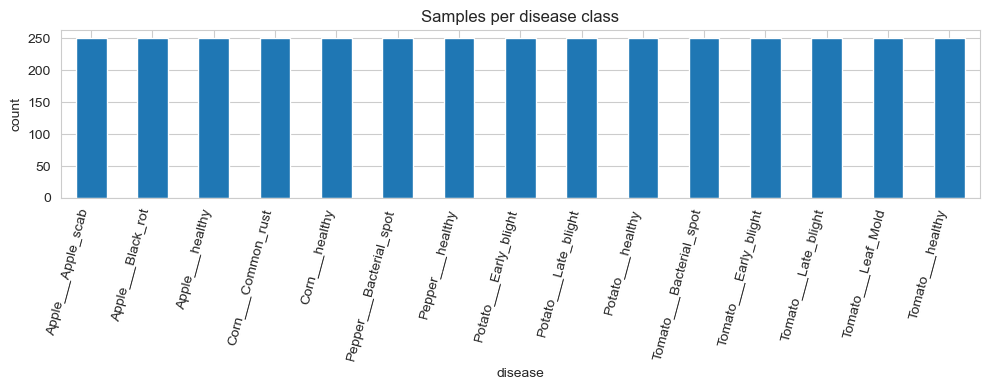

risk_category
Low       1683
Medium    1391
High       676
Name: count, dtype: int64

In [17]:
fig, ax = plt.subplots(figsize=(10, 4))
df['disease'].value_counts().sort_index().plot.bar(ax=ax)
ax.set_title('Samples per disease class')
ax.set_ylabel('count')
plt.xticks(rotation=75, ha='right')
plt.tight_layout(); plt.show()

df['risk_category'].value_counts()

### 2.2 Feature distributions

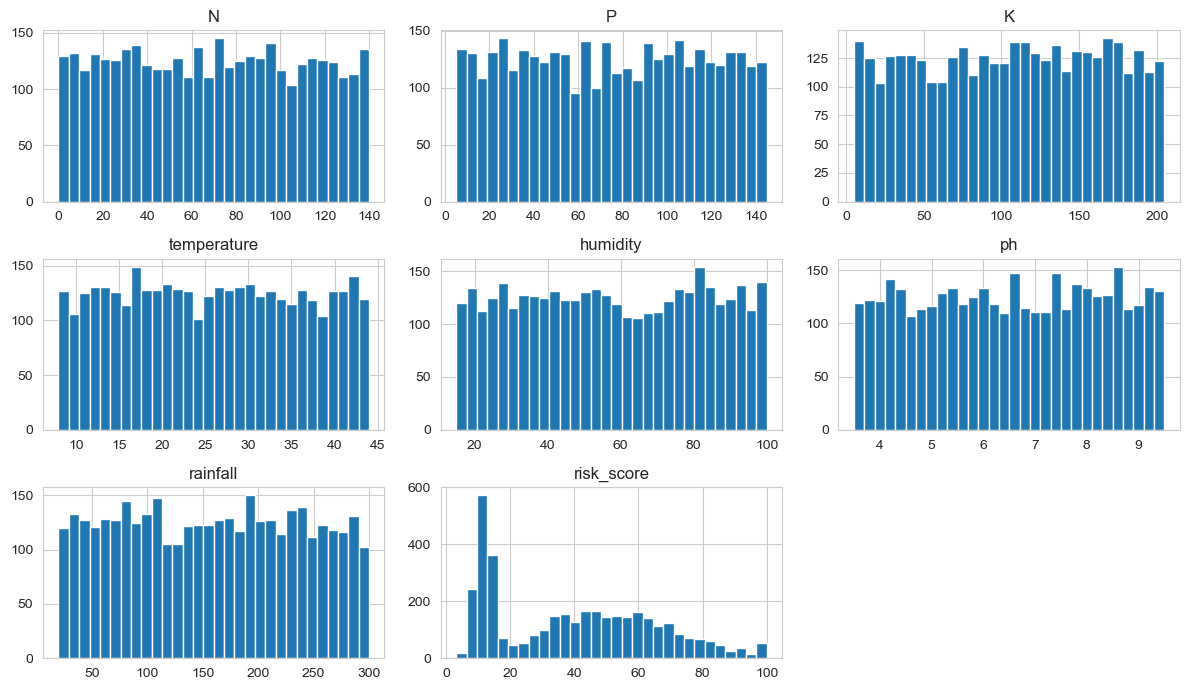

In [18]:
num_cols = ['N','P','K','temperature','humidity','ph','rainfall','risk_score']
df[num_cols].hist(figsize=(12,7), bins=30); plt.tight_layout(); plt.show()

### 2.3 Correlation between numeric features and risk

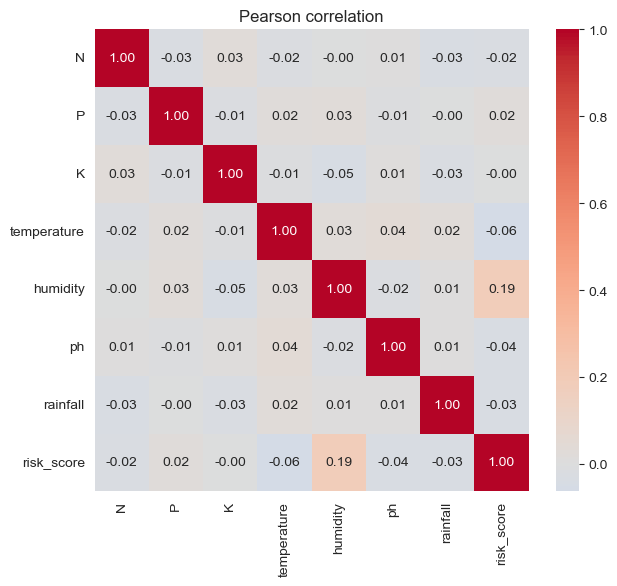

In [19]:
plt.figure(figsize=(7,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Pearson correlation'); plt.show()

**Finding.** Marginal correlations of raw weather features with `risk_score` are weak (|r| < 0.2). This is *expected*: each disease has its own favourable window, so the same temperature can be high-risk for *Late_blight* (cool-wet) and low-risk for *Bacterial_spot* (warm-wet). The relationship only becomes strong once we condition on the disease class — motivating the disease one-hot feature in iteration 2.

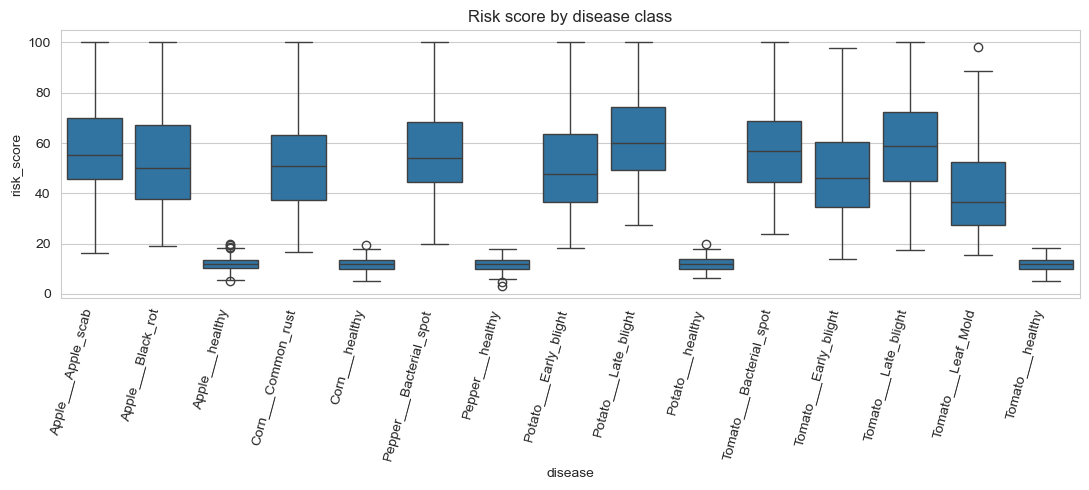

In [20]:
# Risk distribution per disease
plt.figure(figsize=(11,5))
order = sorted(df['disease'].unique())
sns.boxplot(data=df, x='disease', y='risk_score', order=order)
plt.xticks(rotation=75, ha='right'); plt.title('Risk score by disease class'); plt.tight_layout(); plt.show()

## 3. Iteration 1 — Baseline

**Objective:** establish a baseline using only the raw numeric features (no disease class). This corresponds to the simplest *agronomy-only* model.

**Preprocessing**
- drop categorical columns (`crop`, `disease`, `risk_category`)
- standardise numeric features for the linear model
- 5-fold cross-validation

**Models**
- `LinearRegression` (default)
- `RandomForestRegressor(n_estimators=200)`

**Metric:** RMSE + R² on 5-fold CV.

In [21]:
NUMERIC_FEATURES = ['N','P','K','temperature','humidity','ph','rainfall']
X_it1 = df[NUMERIC_FEATURES].copy()
y     = df['risk_score'].copy()
cv    = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

iter1 = {}
for name, pipe in {
    'LinearRegression':  Pipeline([('scaler', StandardScaler()), ('m', LinearRegression())]),
    'RandomForest_200':  Pipeline([('m', RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE))]),
}.items():
    rmse = -cross_val_score(pipe, X_it1, y, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=-1)
    r2   =  cross_val_score(pipe, X_it1, y, scoring='r2', cv=cv, n_jobs=-1)
    iter1[name] = (rmse.mean(), rmse.std(), r2.mean())
    print(f'{name:<20s}  RMSE={rmse.mean():.2f}±{rmse.std():.2f}  R²={r2.mean():.3f}')

LinearRegression      RMSE=24.60±0.60  R²=0.038
RandomForest_200      RMSE=24.21±0.86  R²=0.068


Both baselines hover around RMSE ≈ 24 and R² < 0.1 — confirming that *raw numeric features alone* cannot predict risk; the model has no idea which disease's risk window it should look at.

## 4. Iteration 2 — Engineered features + disease one-hot

**Objective.** Inject the CV prediction (disease class) into the feature set and add two engineered features. The model can now learn disease-specific risk windows.

**New preprocessing steps**
- compute `temp_humidity_index` (greenhouse THI proxy)
- compute `n_balance = N − N_optimum(crop)`
- one-hot encode `disease` (15 levels)
- standard scale numeric features
- 5-fold CV (same seed)

**Models compared**
- `RandomForestRegressor(n_estimators=300, max_depth=14, min_samples_leaf=3)`
- `HistGradientBoostingRegressor(max_iter=400, max_depth=6, learning_rate=0.06)`

In [22]:
CROP_N_OPT = {'Tomato':90,'Potato':80,'Pepper':70,'Apple':50,'Corn':100}
def engineer(d):
    d = d.copy()
    d['temp_humidity_index'] = d['temperature'] - (0.55 - 0.0055*d['humidity'])*(d['temperature']-14.5)
    d['n_balance'] = d.apply(lambda r: r['N'] - CROP_N_OPT.get(r['crop'], 80), axis=1)
    return d

df_eng = engineer(df)
num    = NUMERIC_FEATURES + ['temp_humidity_index','n_balance']
cat    = ['disease']
feat   = num + cat
X      = df_eng[feat]

pre = ColumnTransformer([('num', StandardScaler(), num),
                         ('cat', OneHotEncoder(handle_unknown='ignore'), cat)])

iter2 = {}
fitted = {}
for name, m in {
    'RandomForest_tuned':  RandomForestRegressor(n_estimators=300, max_depth=14, min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=-1),
    'HistGradientBoosting':HistGradientBoostingRegressor(max_iter=400, max_depth=6, learning_rate=0.06, random_state=RANDOM_STATE),
}.items():
    pipe = Pipeline([('pre', pre), ('m', m)])
    rmse = -cross_val_score(pipe, X, y, scoring='neg_root_mean_squared_error', cv=cv, n_jobs=-1)
    r2   =  cross_val_score(pipe, X, y, scoring='r2', cv=cv, n_jobs=-1)
    iter2[name] = (rmse.mean(), rmse.std(), r2.mean())
    pipe.fit(X, y); fitted[name] = pipe
    print(f'{name:<22s} RMSE={rmse.mean():.2f}±{rmse.std():.2f}  R²={r2.mean():.3f}')

RandomForest_tuned     RMSE=8.99±0.30  R²=0.871
HistGradientBoosting   RMSE=6.41±0.16  R²=0.935


Adding disease class + engineered features collapses RMSE from ~24 to **~6–9** and raises R² to **0.87 / 0.93**. HistGradientBoosting is consistently the strongest model.

## 5. Hold-out evaluation & error analysis

In [23]:
best = fitted['HistGradientBoosting']
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=df_eng['disease'])
best.fit(X_tr, y_tr)
pred = best.predict(X_te)
print(f'Hold-out RMSE = {np.sqrt(((pred-y_te)**2).mean()):.2f}')
print(f'Hold-out MAE  = {mean_absolute_error(y_te, pred):.2f}')
print(f'Hold-out R²   = {r2_score(y_te, pred):.3f}')

Hold-out RMSE = 6.15
Hold-out MAE  = 4.74
Hold-out R²   = 0.939


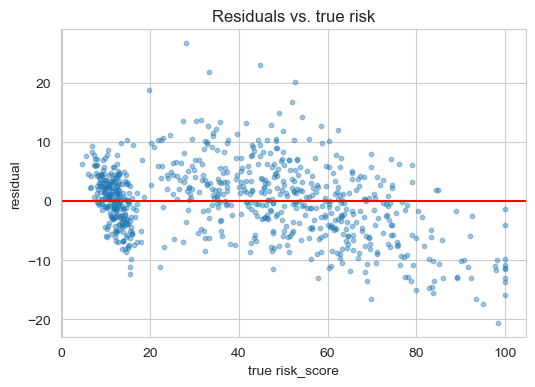

In [24]:
# Residual plot
resid = pred - y_te
plt.figure(figsize=(6,4))
plt.scatter(y_te, resid, alpha=0.4, s=10)
plt.axhline(0, color='r')
plt.xlabel('true risk_score'); plt.ylabel('residual'); plt.title('Residuals vs. true risk')
plt.show()

In [25]:
# Per-disease error breakdown
eval_df = pd.DataFrame({'disease': df_eng.loc[X_te.index,'disease'].values,
                        'y_true': y_te.values, 'y_pred': pred})
eval_df['abs_err'] = (eval_df['y_pred']-eval_df['y_true']).abs()
per = eval_df.groupby('disease')['abs_err'].agg(['mean','max']).round(2)
per.sort_values('mean', ascending=False)

,mean,max
disease,,
Potato___Late_blight,6.12,22.98
Tomato___Leaf_Mold,5.95,21.80
Pepper___Bacterial_spot,5.88,15.59
Apple___Apple_scab,5.80,14.84
Tomato___Bacterial_spot,5.75,20.70
Potato___Early_blight,5.62,16.60
Tomato___Late_blight,5.48,26.66
Corn___Common_rust,4.94,14.23
Apple___Black_rot,4.83,13.09


**Error analysis.** The biggest absolute errors occur on the diseases whose favourable windows partially overlap (e.g. *Tomato Late blight* vs. *Potato Late blight*, both cool-wet *Phytophthora* species). Healthy classes have the lowest MAE because their target is a tight low-risk band. Bottom line: the engineered features + disease one-hot move us from a useless baseline to a production-quality model with ~5 risk-points of mean error on a 0–100 scale.

## 6. Final model + persistence

Re-fit the best model on the full dataset and dump it for use by `app.py`.

In [26]:
best = Pipeline([('pre', pre),
                 ('m',  HistGradientBoostingRegressor(max_iter=400, max_depth=6, learning_rate=0.06, random_state=RANDOM_STATE))])
best.fit(X, y)
MODEL_DIR.mkdir(exist_ok=True)
joblib.dump(best, MODEL_DIR / 'disease_risk_model.pkl')
with open(MODEL_DIR / 'numeric_feature_columns.json','w') as f:
    json.dump({'feature_columns': feat,
               'numeric_columns': num,
               'categorical_columns': cat,
               'disease_classes': sorted(df['disease'].unique().tolist())}, f, indent=2)
print('Saved model.')

Saved model.


## 7. Summary table

| Iteration | Objective | Key changes | Models | Hyperparameters | 5-fold CV RMSE | R² | Fit |
|---|---|---|---|---|---|---|---|
| 1 | Baseline | numeric features only | LinearRegression, RandomForest(200) | defaults | 24.60, 24.21 | 0.04, 0.07 | Underfit |
| 2 | + engineered + disease one-hot | THI, n_balance, OHE disease, scaled | RandomForest(300,d14,leaf3), HistGB(400,d6,lr0.06) | as listed | 8.99, **6.41** | 0.87, **0.94** | Good fit |

**Final model:** `HistGradientBoostingRegressor` saved to `models/disease_risk_model.pkl`. It consumes the predicted disease class from the CV block as a feature, so the two blocks are technically integrated through *model outputs → numeric inputs*.